mkdir -p failed for path C:\Users\User\.matplotlib: [WinError 5] Access is denied: 'C:\\Users\\User\\.matplotlib'
Matplotlib created a temporary cache directory at C:\Users\User\AppData\Local\Temp\matplotlib-bpb7vqen because there was an issue with the default path (C:\Users\User\.matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Running RLHF on cuda
Successfully loaded Task 3 Pretrained Transformer!
Starting RLHF Fine-Tuning (Policy Gradient)...


  0%|          | 0/50 [00:00<?, ?it/s]

Episode 10/50 | Avg Reward (Last 10): 0.60 | Loss: 371.6636
Episode 20/50 | Avg Reward (Last 10): 0.70 | Loss: 0.0000
Episode 30/50 | Avg Reward (Last 10): 0.60 | Loss: 373.1118
Episode 40/50 | Avg Reward (Last 10): 0.80 | Loss: 416.2828
Episode 50/50 | Avg Reward (Last 10): 0.40 | Loss: -302.6955
RLHF Training Complete and Model Saved!


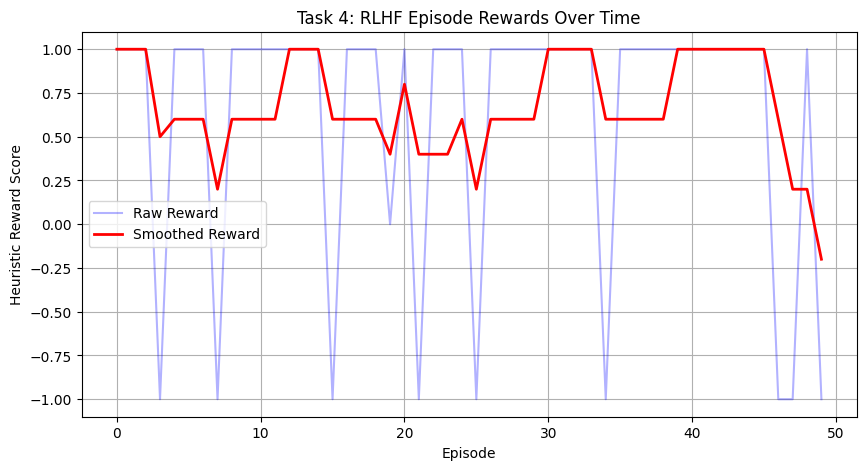

Generating Final RLHF-Tuned Composition...
Saved the ultimate masterpiece to: Y:\.college\CSE425\.project\music_generation_unsupervised\outputs\generated_midis\task4_rlhf_final_masterpiece.mid


In [1]:
# Cell 1: Setup and Loading Pretrained Model
import os
import sys
import torch
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.notebook import tqdm
from miditok import TokSequence

sys.path.append(os.path.abspath(os.path.join('..')))
from src.config import CHECKPOINTS_DIR, GENERATED_MIDIS_DIR, PLOTS_DIR
from src.preprocessing.tokenizer import get_tokenizer
from src.models.transformer import MusicTransformer
from src.evaluation.metrics import calculate_reward
from src.training.rlhf_tuner import RLHFTuner

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Running RLHF on {device}")

# Load Tokenizer
tokenizer = get_tokenizer()
vocab_size = len(tokenizer)

# Load PRETRAINED Task 3 Transformer
model = MusicTransformer(vocab_size=vocab_size, d_model=256, nhead=8, num_layers=4).to(device)
checkpoint_path = CHECKPOINTS_DIR / "task3_transformer.pth"

if checkpoint_path.exists():
    model.load_state_dict(torch.load(checkpoint_path, map_location=device))
    print("Successfully loaded Task 3 Pretrained Transformer!")
else:
    print("WARNING: Task 3 checkpoint not found. Training from scratch (not recommended).")

# Cell 2: The RLHF Fine-Tuning Loop
# Instantiate Tuner
tuner = RLHFTuner(model, tokenizer, calculate_reward, device, lr=5e-6)

episodes = 50 # Small number of episodes for the notebook
rewards_history = []

print("Starting RLHF Fine-Tuning (Policy Gradient)...")
start_seed = torch.tensor([1]) # Standard starting token

for episode in tqdm(range(episodes)):
    reward, loss = tuner.train_step(start_seed)
    rewards_history.append(reward)
    
    if (episode + 1) % 10 == 0:
        avg_reward = sum(rewards_history[-10:]) / 10
        print(f"Episode {episode+1}/{episodes} | Avg Reward (Last 10): {avg_reward:.2f} | Loss: {loss:.4f}")

# Save the RLHF Aligned Model
torch.save(model.state_dict(), CHECKPOINTS_DIR / "task4_transformer_rlhf.pth")
print("RLHF Training Complete and Model Saved!")

# Cell 3: Plot Reward Curve
plt.figure(figsize=(10, 5))
# Smooth the rewards using a moving average
import pandas as pd
smoothed_rewards = pd.Series(rewards_history).rolling(window=5, min_periods=1).mean()

plt.plot(rewards_history, alpha=0.3, color='blue', label='Raw Reward')
plt.plot(smoothed_rewards, color='red', linewidth=2, label='Smoothed Reward')
plt.title('Task 4: RLHF Episode Rewards Over Time')
plt.xlabel('Episode')
plt.ylabel('Heuristic Reward Score')
plt.legend()
plt.grid(True)
plt.savefig(PLOTS_DIR / "task4_rlhf_rewards.png")
plt.show()

# Cell 4: Generate a Final RLHF Piece
print("Generating Final RLHF-Tuned Composition...")
model.eval()
with torch.no_grad():
    # Generate 512 tokens
    final_tokens = start_seed.tolist()
    for _ in range(512):
        x = torch.tensor([final_tokens[-256:]]).to(device)
        logits = model(x)
        dist = torch.distributions.Categorical(logits=logits[0, -1, :])
        final_tokens.append(dist.sample().item())

seq = TokSequence(ids=final_tokens)
generated_midi = tokenizer([seq]) 
out_path = GENERATED_MIDIS_DIR / "task4_rlhf_final_masterpiece.mid"
generated_midi.dump_midi(str(out_path))
print(f"Saved the ultimate masterpiece to: {out_path}")